# Python with Pandas - Hostnames Projects

Roger González Sánchez
<br>
contact.rogergonzalez@gmail.com
<br>
https://www.linkedin.com/in/rogergonzalezsanchez/

**Project Overview: Advanced Python Programming Module Practice**

This project was developed as part of the Advanced Python Programming module to consolidate and demonstrate the knowledge acquired throughout the course. The majority of the concepts needed were covered in lectures and instructional videos, which provided examples to guide the development process. Whenever I encountered doubts, I referred to the provided documentation and example code, as well as the video tutorials, to successfully complete the tasks.

Important note: Communication with the instructor for code review or hints before submission was not permitted, so this project fully reflects my independent problem-solving and coding skills.

**Project Description**

Using the skills learned in both the Foundations of Python and Advanced Python modules, I designed and implemented an algorithm to generate a dataset of random server hostnames based on given weights. From this dataset, I created a Pandas DataFrame to organize and manipulate the data efficiently for visualization.

Building upon the dataset, I used Matplotlib as well as Seaborn to create a series of insightful visualizations that help analyze and interpret the data, demonstrating practical data visualization techniques.

**Technical Highlights** 

- Data generation: Developed a Python algorithm to produce randomized server names following specific patterns.
- Data manipulation: Constructed and managed a Pandas DataFrame from the generated dataset.
- Data visualization: Created multiple plots with Matplotlib to explore the distribution and relationships within the data.
- Independent learning: Applied documentation and tutorial videos to overcome challenges and refine the code.

This project showcases my ability to combine programming fundamentals with advanced techniques to produce structured data and meaningful visual insights, reinforcing my expertise in Python for data-driven applications.


I have broken down the task into two main sections. The first one will be referred to the import of the necessary modules and the creation of the different functions. In the “analytics” part I have created everything related to Pandas and the graphs.

## INTRODUCTION

Next I have imported the different modules that I will use to develop my code. These are pandas, random, matplotlib and seaborn.

In [30]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

In this first part of the task I have created the different functions (with their respective weight percentages in each one) that I will use to create the different hostnames, operating systems, environments, countries, nodes and finally, the set_dataframe function that will take all the data generated by the other functions and will first create a dictionary to later create the dataframe “df”.



### Hostnames() function definition


In [4]:
def set_hostnames(number_of_hosts):
    os = ["L", "S", "A", "H"]
    proportions_os = [0.4, 0.3, 0.2, 0.1]

    env = ["D", "I", "T", "S", "P"]
    proportions_env = [0.1, 0.1, 0.25, 0.25, 0.30]

    country = ["NOR", "FRA", "ITA", "ESP", "DEU", "IRL"]
    proportions_country = [0.06, 0.09, 0.16, 0.16, 0.23, 0.30]

    # List to store the generated hostnames
    hostnames_list = []

    while len(hostnames_list) < number_of_hosts:
        # Random selection of the first 3 groups
        first_character = random.choices(os, proportions_os)[0]
        second_character = random.choices(env, proportions_env)[0]
        third_group_characters = random.choices(country, proportions_country)[0]

        # Generate the hostname prefix without the number
        hostname_without_numbers = first_character + second_character + third_group_characters

        # Generate the node number and format it with 3 digits
        number = str(random.randint(1, 999)).zfill(3)

        # Combine the prefix with the number
        hostname = hostname_without_numbers + number

        # Check if the hostname already exists
        if hostname not in hostnames_list:
            hostnames_list.append(hostname)  # Only add if it doesn't exist

    return hostnames_list


### get_os() function

In [5]:
def get_os(hostnames):
    os_list = []
    for host in hostnames:
        if host[0] == "L":
            os_list.append("Linux")
        elif host[0] == "S":
            os_list.append("Solaris")
        elif host[0] == "A":
            os_list.append("AIX")
        elif host[0] == "H":
            os_list.append("HP-UX")
        else:
            os_list.append("Unknown")

    return os_list

### get_environment() function

In [6]:
def get_environment(hostnames_list):

    environments = []

    for host in hostnames_list:
        if host[1] == "D":
            environments.append("Development")

        elif host[1] == "I":
            environments.append("Integration")

        elif host[1] == "T":
            environments.append("Testing")

        elif host[1] == "S":
            environments.append("Staging")

        elif host[1] == "P":
            environments.append("Production")

        else:
            environments.append("Unknown")

    return environments

### get_country() function

In [11]:
def get_country(hostnames):
    country_list = []
    for host in hostnames:
        if host[2:5] == "NOR":
            country_list.append("Norway")

        elif host[2:5] == "DEU":
            country_list.append("Germany")

        elif host[2:5] == "ITA":
            country_list.append("Italy")

        elif host[2:5] == "ESP":
            country_list.append("Spain")

        elif host[2:5] == "IRL":
            country_list.append("Ireland")

        elif host[2:5] == "FRA":
            country_list.append("France")

        else:
            country_list.append("Unknown")

    return country_list

### get_node() function

In [12]:
def get_node(hostnames):
    node_list = []
    for host in hostnames:
        node_list.append(host[5:9])

    return node_list

### set_dataframe() function

In [13]:
def set_dataframe(count):

    hosts = set_hostnames(count)
    os = get_os(hosts)
    env = get_environment(hosts)
    country = get_country(hosts)
    node = get_node(hosts)

    #The results are lists that we will convert into a dictionary to be able to pass the data to Pandas.

    data_dictionary = {"hostname":hosts, "os": os, "environment":env, "country":country, "node": node}

    df = pd.DataFrame(data_dictionary)
    return df

## ANALYSIS

Once all the necessary functions to generate our dataframe have been created, we will ask the user to input how many hosts they want to create in the dataframe. Keep in mind that each time an input is entered, the dataframe will change.

### Pandas

In [24]:
count = int(input("How many hosts do you want? "))

In [25]:
# Once we have the dictionary, we create the dataframe and display it:

df = set_dataframe(count)
df

,hostname,os,environment,country,node
0,APITA054,AIX,Production,Italy,054
1,ATESP371,AIX,Testing,Spain,371
2,STITA717,Solaris,Testing,Italy,717
3,SSFRA452,Solaris,Staging,France,452
4,LPESP834,Linux,Production,Spain,834
...,...,...,...,...,...
995,SSESP883,Solaris,Staging,Spain,883
996,ASDEU234,AIX,Staging,Germany,234
997,ATIRL241,AIX,Testing,Ireland,241
998,SPIRL221,Solaris,Production,Ireland,221


In [27]:
try:
    df.to_csv(
        r"hosts.csv",
        encoding="ISO-8859-1"  # Avoid issues with accents and special characters
    )
    print("CSV file successfully created.")
except Exception as e:
    print(f"An error occurred while creating the CSV file: {e}")

CSV file successfully created.


### Generate a single chart grouping environments by country

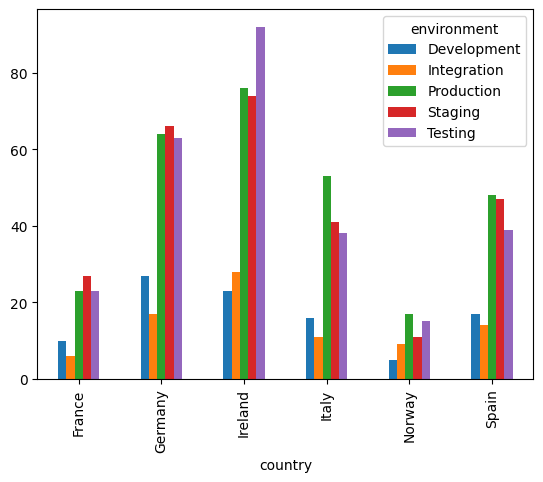

In [28]:
df_grouped_country = df.groupby(["country", "environment"]).size()

df_grouped_country.unstack().plot(kind="bar");

### Create a figure with 4 plots arranged in a 2-row by 2-column grid.

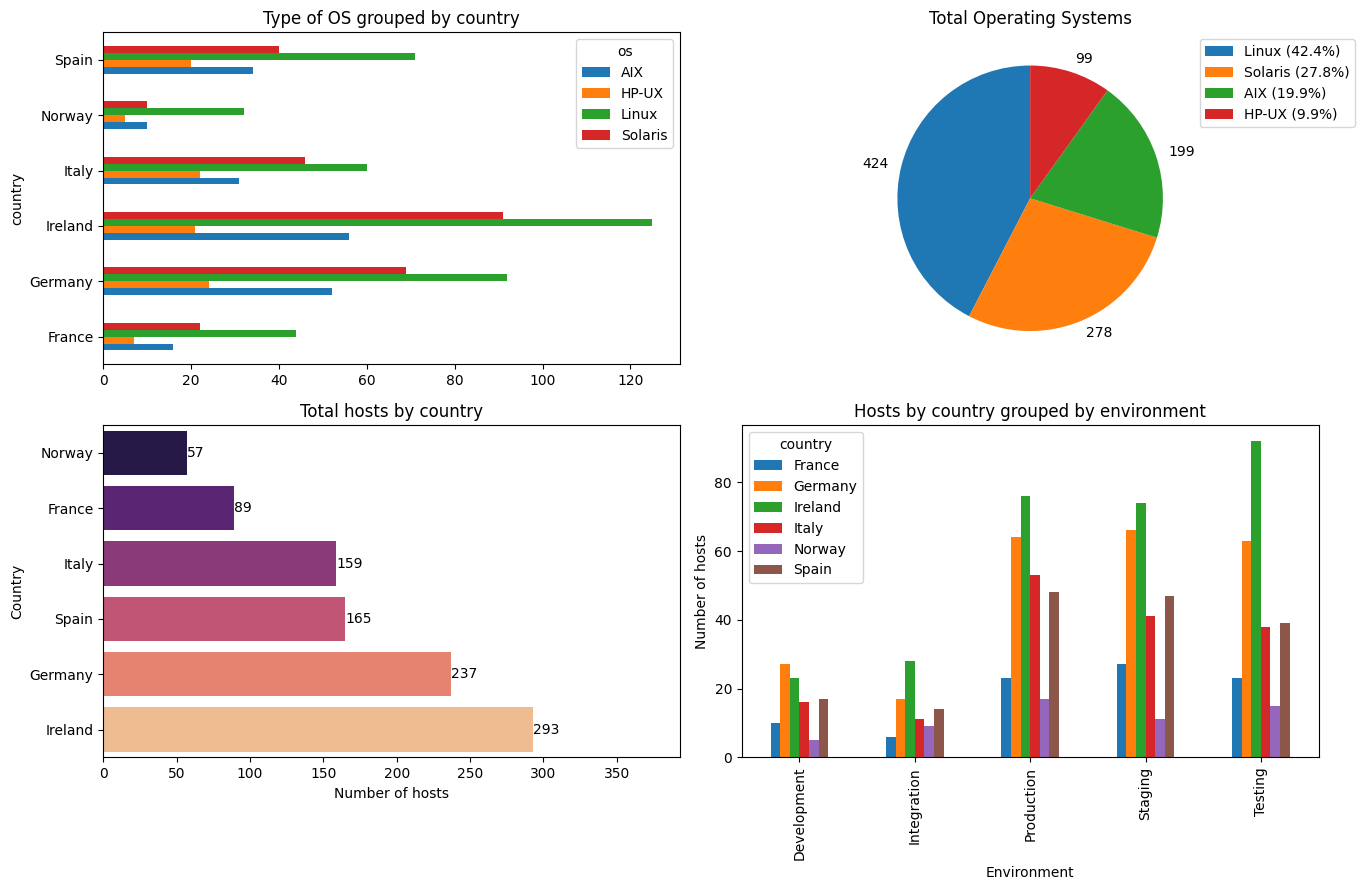

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

#-------------------------- PLOT 1 -------------------------
# Create the dataframe 'type_os' with the series "country" and "os", then call .unstack() to group by country.
type_os = df.groupby(["country", "os"]).size().unstack()

type_os.plot(
    kind="barh",
    ax=axs[0, 0]
)

axs[0, 0].set_title("Type of OS grouped by country")

#-------------------------- PLOT 2 --------------------------
# First, create the dataframe total_os using reset_index to work with both series (os and count)
total_os = df["os"].value_counts().reset_index()
total_os.columns = ["os", "count"]

# Add a new column called "Percentages"
total_os["Percentages"] = total_os["count"] / total_os["count"].sum() * 100
total_os["Percentages"] = total_os["Percentages"].round(2)  # Round percentages to two decimals

labels_legend = total_os["os"] + " (" + total_os["Percentages"].astype(str) + "%)"

axs[0, 1].pie(
    total_os["count"],
    labels=total_os["count"],
    startangle=90
)

axs[0, 1].legend(labels=labels_legend, loc="upper right", bbox_to_anchor=(1.5, 1))
axs[0, 1].set_title("Total Operating Systems")

#-------------------------- PLOT 3 --------------------------
total_hosts = df["country"].value_counts().sort_values().reset_index()
total_hosts.columns = ["country", "count"]

# Use seaborn to create a bar plot at axs[1, 0]
sns.barplot(
    x=total_hosts["count"],   # X axis
    y=total_hosts["country"], # Y axis
    hue=total_hosts["country"],
    palette="magma",
    ax=axs[1, 0]
)

# Define a function to add labels to bars using a for loop
# Iterates over all elements of list or array x by index i, adding text labels to the plot
def add_labels(x, y):
    for i in range(len(x)):
        axs[1, 0].text(
            x[i],               # X coordinate for the text label
            i,                  # Y coordinate for the text label (index of the element)
            f'{x[i]:.0f}',      # Text to show (rounded integer value of x[i])
            va='center',        # vertical alignment
            ha='left',          # horizontal alignment
            fontsize=10,
            color='black'
        )

add_labels(total_hosts["count"], total_hosts["country"])

axs[1, 0].set_xlim(0, max(total_hosts["count"].values) + 100)  # Add padding of 100 units to the right of the max count
axs[1, 0].set_xlabel("Number of hosts")
axs[1, 0].set_ylabel("Country")

axs[1, 0].set_title("Total hosts by country")

#-------------------------- PLOT 4 --------------------------
# Use unstack(0) to move the first level of the index ("country") to columns
# So the index becomes "environment" instead of "country"
hosts_env = df.groupby(["country", "environment"]).size().unstack(0)

hosts_env.plot(
    kind="bar",
    xlabel="Environment",
    ylabel="Number of hosts",
    ax=axs[1, 1]
)

axs[1, 1].set_title("Hosts by country grouped by environment")



plt.tight_layout()
plt.show();